In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

c:\Users\Admin\Desktop\MAIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL = "Qwen/Qwen3-8B"
TOKENIZER = AutoTokenizer.from_pretrained (MODEL)

In [3]:
dataset = load_dataset ("parquet", data_files = r"C:\Users\Admin\Desktop\MAIA\SLD\Datasets\DatasetTokenizado.parquet", split = "train")

display (dataset.features)
print (dataset[0])
print (dataset)

{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

{'input_ids': [151644, 872, 198, 1912, 1709, 21791, 297, 2543, 963, 10681, 815, 1036, 32, 8376, 64, 29134, 7806, 469, 57608, 264, 1197, 9696, 854, 2053, 1617, 264, 19408, 291, 10782, 5411, 2635, 768, 1137, 64, 30, 151645, 198, 151644, 77091, 198, 151667, 271, 151668, 271, 42990, 2543, 963, 10681, 815, 7756, 64, 264, 139669, 2994, 12139, 86585, 384, 653, 68279, 15027, 91724, 83, 23137, 17141, 1351, 33465, 47271, 9823, 2782, 13, 83767, 485, 1709, 438, 45962, 70502, 309, 264, 4536, 71, 685, 409, 57608, 438, 1367, 265, 10938, 384, 949, 84110, 2643, 41398, 36152, 13, 19801, 79594, 11, 4443, 1947, 288, 3413, 70502, 30741, 348, 1659, 2643, 41398, 61862, 264, 140031, 1709, 1443, 2758, 645, 297, 20009, 54639, 384, 1197, 9696, 297, 14116, 2994, 19345, 51348, 11, 976, 20563, 409, 15632, 277, 5686, 19529, 57608, 12393, 297, 1367, 265, 10938, 13, 151645, 198], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [4]:
TOKENS = []

for x in dataset["input_ids"]:

    TOKENS.append (len (x)) # len é fulcral para ter o NÚMERO DE TOKENS

################################################################################

#print (f"Tokens Processados no Treino: {np.sum (TOKENS)} tokens") # 619947163
#print (len(TOKENS)) # 774447
"""
Aqui pode parecer estranho não ser igual ao que o Config mostra mas é preciso não esquecer que este valor corresponde à Tokenização COM Chat Template.
Este valor é importante porque este é o número de Tokens que vão ser processados no TREINO.

len (TOKENS) é excelente para mostrar que todos os exemplos estão tokenizados.
"""
################################################################################

MIN = min(TOKENS)
print (f"MINIMUN: {MIN} tokens")

MAX = max(TOKENS)
print (f"MAX: {MAX} tokens")

MÉDIA = np.mean (TOKENS)
print (f"Média: {MÉDIA:.0f} tokens")

P50 = np.percentile (TOKENS, 50)
print (f"Mediana: {P50:.0f} tokens")

P75 = np.percentile (TOKENS, 75)
print (f"P75: {P75:.0f} tokens")

P90 = np.percentile (TOKENS, 90)
print (f"P90: {P90:.0f} tokens")

P95 = np.percentile (TOKENS, 95)
print (f"P95: {P95:.0f} tokens")

P99 = np.percentile (TOKENS, 99)
print (f"P99: {P99:.0f} tokens")

MINIMUN: 26 tokens
MAX: 5128 tokens
Média: 801 tokens
Mediana: 727 tokens
P75: 1352 tokens
P90: 1594 tokens
P95: 1716 tokens
P99: 2179 tokens


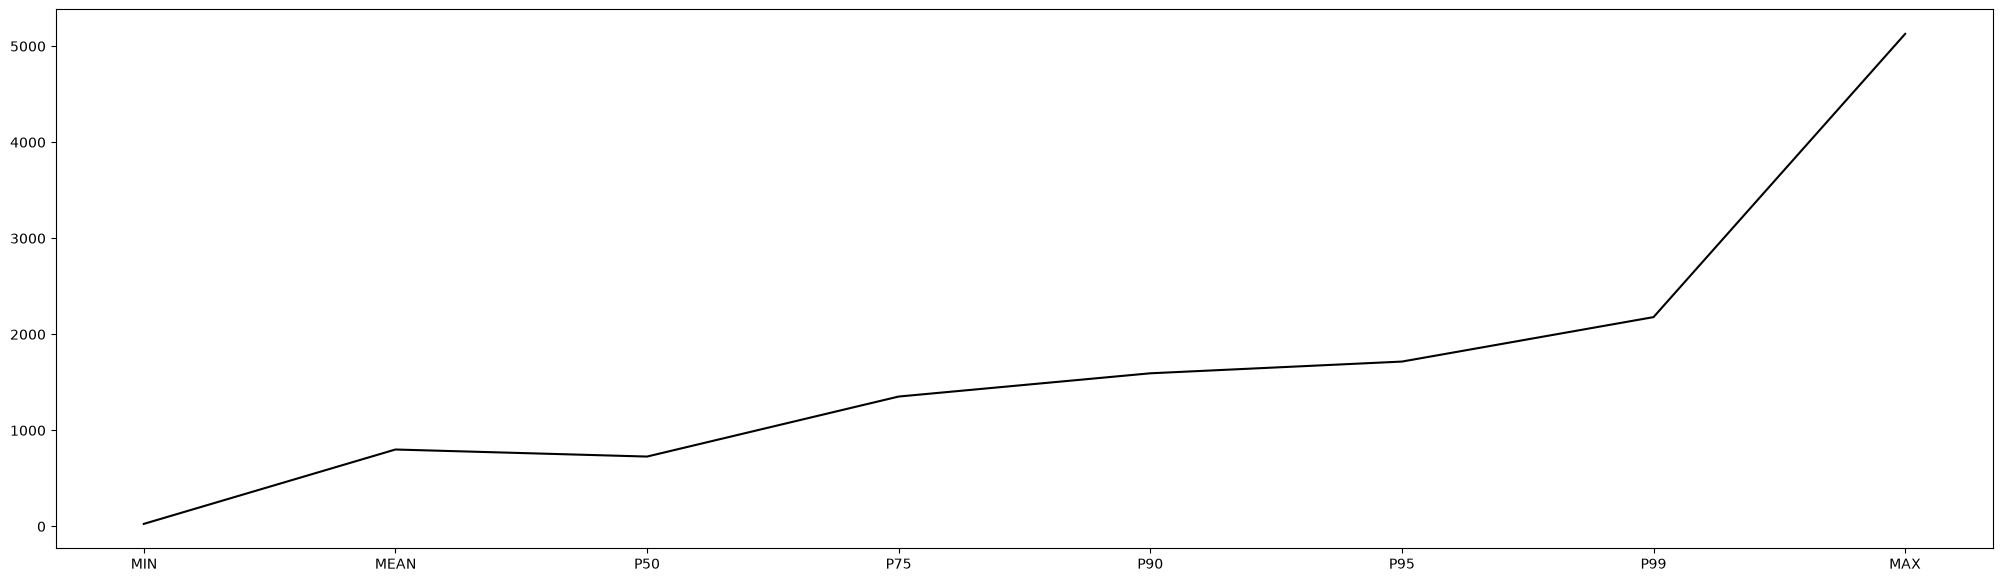

In [7]:
x = ["MIN", "MEAN", "P50", "P75", "P90", "P95", "P99", "MAX"]
y = [MIN, MÉDIA, P50, P75, P90, P95, P99, MAX]

"""
y |
  |
  |
  |
  |_ _ _ _ _ _ _ x
"""

plt.figure (figsize = (25, 7))
plt.plot (x, y, color = "black")
plt.show ()